# Illustration of the frequency content

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
from scipy.fft import fft2, fftshift, ifft2, ifftshift
plt.style.use('../../src/bip.mplstyle')

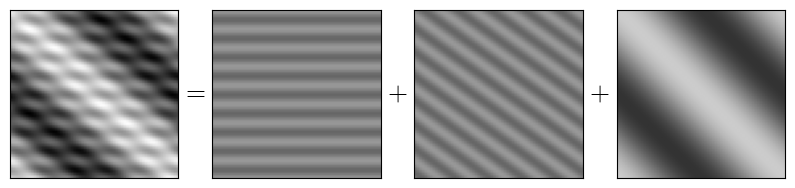

In [2]:
# Taille des images
N = 64

# Indices des oscillations
idx = [
    [9,   0, 0, 1],
    [9, 1/5, 1, 1],
    [2, 1/4, 0, 3],
]
I = len(idx)

# Préparation de l'affichage
fig, axs = plt.subplots(1,I+1, figsize=(10,5))

i = 0
G = np.zeros((N,N), dtype="complex")
for rho, theta, c, ampl in idx:
    
    i += 1
    
    e = rho * np.exp(1j*theta*np.pi)
    a = int(np.round(np.real(e)))
    b = int(np.round(np.imag(e)))
    
    F = np.zeros((N,N), dtype="complex")
    F[N//2-a,N//2+b] = ampl * 1/2 * (1 if c==0 else +1j)
    F[N//2+a,N//2-b] = ampl * 1/2 * (1 if c==0 else -1j)
    G += F
    
    # Affichage
    f = np.real(ifft2(ifftshift(F)))
    axs[i].imshow(f, "gray", vmin=-1.22e-3, vmax=1.22e-3)
    
# Affichage
g = np.real(ifft2(ifftshift(G)))
axs[0].imshow(g, "gray", vmin=-1.22e-3, vmax=1.22e-3)

# Axes et labels
for i in range(I+1):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
axs[1].set_ylabel("=", fontsize=20, labelpad=11, rotation=0, va="center")
for i in range(2,I+1):
    axs[i].set_ylabel("+", fontsize=20, labelpad=11, rotation=0, va="center")
    
plt.savefig("fourier-decomposition.svg")
plt.show()

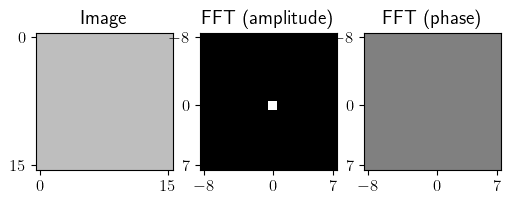

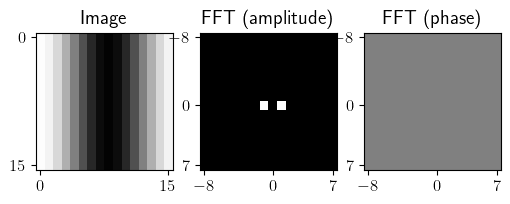

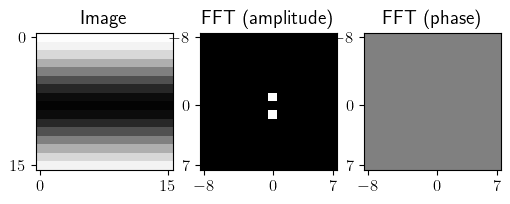

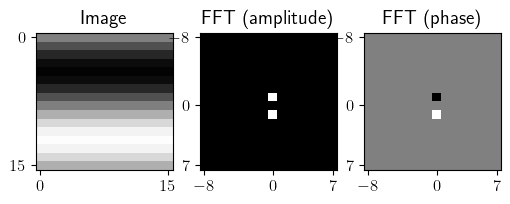

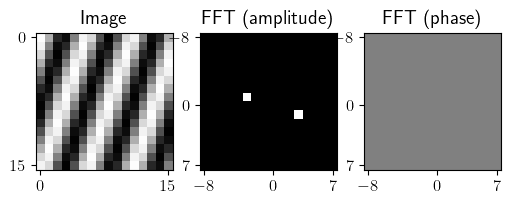

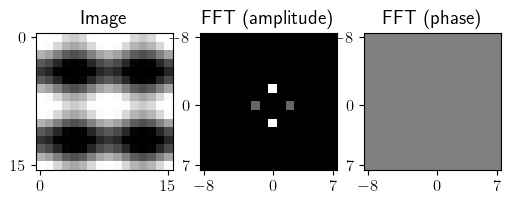

In [3]:
# Taille de l'image
N = 16

# Pixels dans le domaine spectral à considérer : (x, y, amplitude, phase)
px = (
    (( 0, 0, 1, 0), ),
    (( 0, 1, 1, 0),       ( 0, -1, 1, 0), ),
    (( 1, 0, 1, 0),       ( -1, 0, 1, 0), ),
    (( 1, 0, 1, np.pi/2), ( -1, 0, 1, -np.pi/2), ),
    (( 1, 3, 1, 0),       ( -1, -3, 1, 0), ),
    (( 2, 0, 1, 0),       ( -2, 0, 1, 0),        ( 0, 2, .4, 0),   ( 0, -2, .4, 0), ),
)
K = len(px)

# Positions des axes
pos = [None]*3

# Affichage des images ########################################################
for k in range(K):
    
    # Initialisation de la FFT et ajout des pixels
    X = np.zeros((N,N), dtype="complex")
    for i, j, a, p in px[k]:
        X[i,j] += .5e3 * a * np.exp(p*1j)
    
    # FFT inverse
    x = np.fft.ifft2(X)
    x = np.real(x)

    # FFT shiftée
    X = np.fft.fftshift(X)

    # Affichage
    fig, axs = plt.subplots(1, 3, figsize=(6,2))
    
    # Affichage de l'image de la base
    axs[0].imshow(x, cmap='gray', vmin=-4, vmax=4)
    axs[0].set_xticks([0, 15])
    axs[0].set_yticks([0, 15])
    axs[0].set_title("Image", fontsize=14)
    pos[0] = axs[0].get_position()
    
    # Affichage du module de la FFT
    axs[1].imshow(np.abs(X), cmap='gray')#, vmin=0, vmax=.5)
    axs[1].set_xticks([0, 8, 15])
    axs[1].set_xticklabels(["$-8$", "$0$", "$7$"])
    axs[1].set_yticks([0, 8, 15])
    axs[1].set_yticklabels(["$-8$", "$0$", "$7$"])
    axs[1].set_title("FFT (amplitude)", fontsize=14)
    pos[1] = axs[1].get_position()
    
    # Affichage de la phase de la FFT
    axs[2].imshow(np.angle(X), cmap='gray', vmin=-np.pi/2, vmax=np.pi/2)
    axs[2].set_xticks([0, 8, 15])
    axs[2].set_xticklabels(["$-8$", "$0$", "$7$"])
    axs[2].set_yticks([0, 8, 15])
    axs[2].set_yticklabels(["$-8$", "$0$", "$7$"])
    axs[2].set_title("FFT (phase)", fontsize=14)
    pos[2] = axs[2].get_position()
    
    # Enregistrement et affichage
    plt.savefig(f"fourier-{k}.svg", dpi=200, facecolor='None', edgecolor='None', transparent=False, bbox_inches='tight')    
    plt.show()

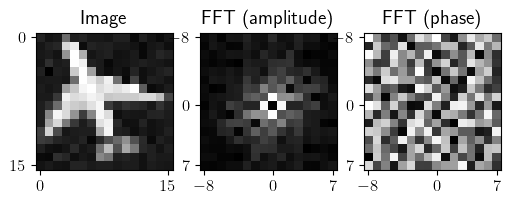

In [4]:
x = io.imread('plane16.jpg')
x = x - np.mean(x)
N = 16
    
# FFT
X = np.fft.fft2(x)
X = np.fft.fftshift(X)

# Affichage
fig, axs = plt.subplots(1, 3, figsize=(6,2))

# Affichage de l'image de la base
axs[0].imshow(x, cmap='gray')
axs[0].set_xticks([0, 15])
axs[0].set_yticks([0, 15])
axs[0].set_title("Image", fontsize=14)

# Affichage du module de la FFT
axs[1].imshow(np.abs(X), cmap='gray')
axs[1].set_xticks([0, 8, 15])
axs[1].set_xticklabels(["$-8$", "$0$", "$7$"])
axs[1].set_yticks([0, 8, 15])
axs[1].set_yticklabels(["$-8$", "$0$", "$7$"])
axs[1].set_title("FFT (amplitude)", fontsize=14)

# Affichage de la phase de la FFT
axs[2].imshow(np.angle(X), cmap='gray')
axs[2].set_xticks([0, 8, 15])
axs[2].set_xticklabels(["$-8$", "$0$", "$7$"])
axs[2].set_yticks([0, 8, 15])
axs[2].set_yticklabels(["$-8$", "$0$", "$7$"])
axs[2].set_title("FFT (phase)", fontsize=14)

# Enregistrement et affichage
plt.savefig("fourier-full.svg", dpi=200, facecolor='None', edgecolor='None', transparent=False, bbox_inches='tight')    
plt.show()